<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask: 
      linear-gradient(#fff 0 0) content-box, 
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>05 $\rightarrow$ Vehicle Detection in Video Streams</b>
  <br>
  <span style="color:#ffb5a7; font-size: 18px;">(Highway Traffic Surveillance & Moving Vehicle Analytics Pipeline)</span>
</div>

---

## Overview
In this notebook, we detect **Vehicles / Cars** in traffic video streams using OpenCV and the `haarcascade_car.xml` model.

### Key Concepts Covered:
1. Loading and inspecting traffic video streams (`assets/video/Vehicles.mp4`).
2. Detecting passing vehicles frame-by-frame with `haarcascade_car.xml`.
3. Frame sampling and 4-frame visual gallery display in Matplotlib.
4. Tracking vehicle density and flow over time.
5. Complete standalone video playback loop.

---

# Table of Contents 

1. [Import Libraries](#1-import-libraries)
2. [Load the Pre-Trained Vehicle Classifier](#2-load-the-pre-trained-vehicle-classifier)
3. [Inspect Traffic Video Metadata](#3-inspect-traffic-video-metadata)
4. [Sample Traffic Frames and Detect Vehicles](#4-sample-traffic-frames-and-detect-vehicles)
5. [Visualizations](#5-visualizations)
   - 5.1 [Plot 1: 4-Frame Vehicle Detection Gallery](#51-plot-1-4-frame-vehicle-detection-gallery)
   - 5.2 [Plot 2: Traffic Density Trend Over Time (Flow Analytics)](#52-plot-2-traffic-density-trend-over-time-flow-analytics)
6. [Complete Standalone Video Playback Loop](#6-complete-standalone-video-playback-loop)
7. [Key Takeaways](#7-key-takeaways)

---

<a id="1-import-libraries"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">1. Import Libraries</span>

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from PIL import Image
%matplotlib inline


<a id="2-load-the-pre-trained-vehicle-classifier"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">2. Load the Pre-Trained Vehicle Classifier</span>

In [2]:
car_cascade_path = 'Haarcascades/haarcascade_car.xml'
car_classifier = cv2.CascadeClassifier(car_cascade_path)

if car_classifier.empty():
    print("Error: Could not load car cascade classifier!")
else:
    print("Car classifier loaded successfully!")

Car classifier loaded successfully!


<a id="3-inspect-traffic-video-metadata"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">3. Inspect Traffic Video Metadata</span>

In [3]:
video_path = 'assets/video/Vehicles.mp4'
if not os.path.exists(video_path):
    print(f"Error: Video file not found at '{video_path}'.")
else:
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration = total_frames / fps if fps > 0 else 0

    print(f"Video File       : {video_path}")
    print(f"Resolution       : {width} x {height} px")
    print(f"Frame Rate (FPS) : {fps:.1f}")
    print(f"Total Frames     : {total_frames}")
    print(f"Duration         : {duration:.2f} seconds")
    cap.release()


Video File       : assets/video/Vehicles.mp4
Resolution       : 1280 x 720 px
Frame Rate (FPS) : 30.0
Total Frames     : 984
Duration         : 32.83 seconds


<a id="4-sample-traffic-frames-and-detect-vehicles"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">4. Sample Traffic Frames and Detect Vehicles</span>

In [4]:
sample_frame_indices = [20, 50, 80, 110]
sampled_car_results = []

cap = cv2.VideoCapture(video_path)

for frame_idx in sample_frame_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame_bgr = cap.read()
    
    if not ret:
        print(f"Warning: Could not read frame {frame_idx}")
        continue
        
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    frame_gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    
    cars = car_classifier.detectMultiScale(frame_gray, scaleFactor=1.15, minNeighbors=3)
    
    annotated_frame = frame_rgb.copy()
    for (x, y, w, h) in cars:
        cv2.rectangle(annotated_frame, (x, y), (x + w, y + h), (255, 0, 0), 4)
        cv2.putText(annotated_frame, "Car", (x, y - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
        
    timestamp = frame_idx / fps
    sampled_car_results.append({
        'frame_idx': frame_idx,
        'timestamp': timestamp,
        'image': annotated_frame,
        'count': len(cars)
    })
    print(f"Frame {frame_idx:3d} ({timestamp:.2f}s): {len(cars)} vehicle(s) detected")

cap.release()

Frame  20 (0.67s): 8 vehicle(s) detected
Frame  50 (1.67s): 7 vehicle(s) detected
Frame  80 (2.67s): 7 vehicle(s) detected
Frame 110 (3.67s): 7 vehicle(s) detected


<a id="5-visualizations"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">5. Visualizations</span>

<a id="51-plot-1-4-frame-vehicle-detection-gallery"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">5.1 Plot 1: 4-Frame Vehicle Detection Gallery</span>

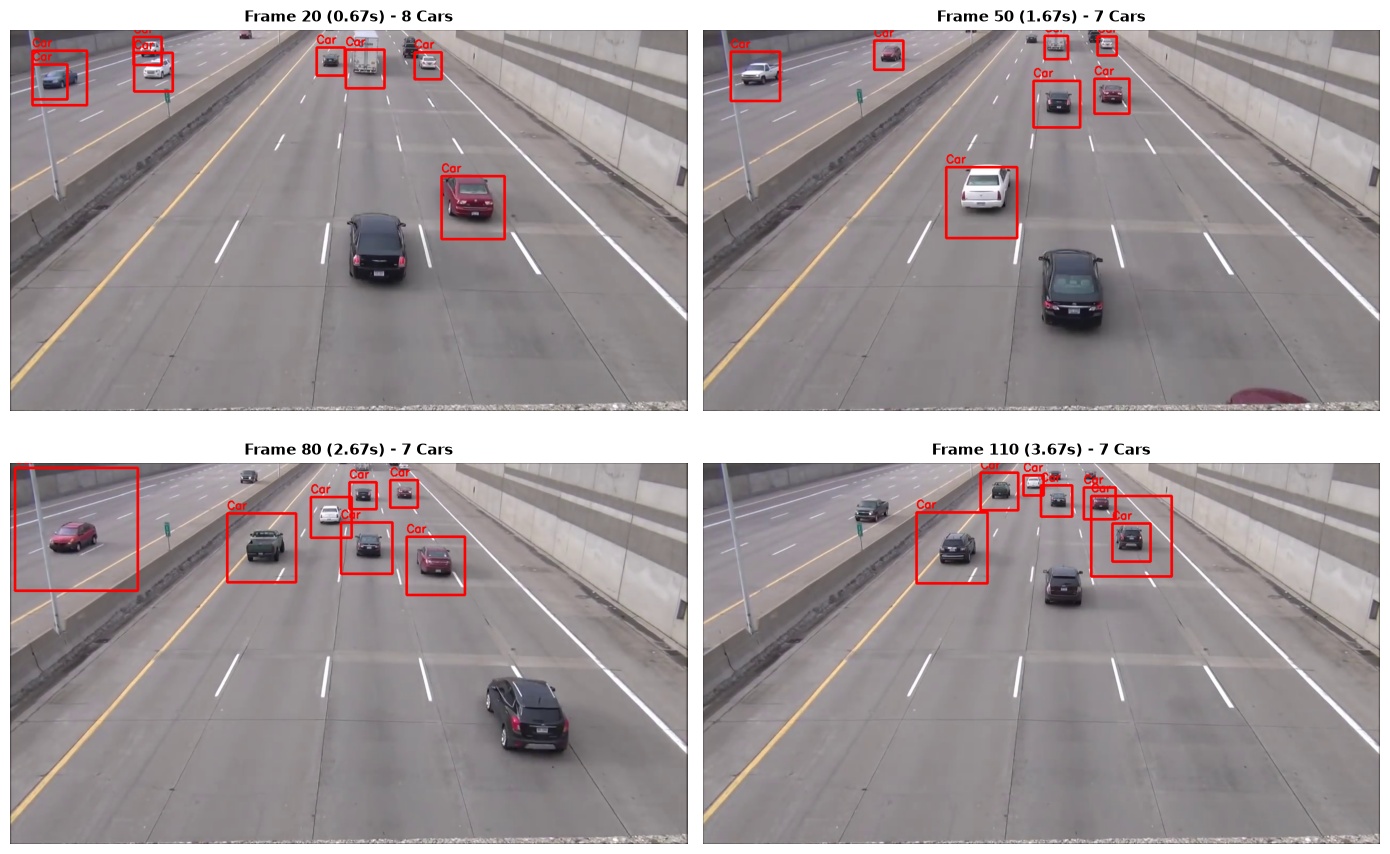

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, res in enumerate(sampled_car_results):
    axes[i].imshow(res['image'])
    axes[i].set_title(f"Frame {res['frame_idx']} ({res['timestamp']:.2f}s) - {res['count']} Cars",
                      fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

<a id="52-plot-2-traffic-density-trend-over-time-flow-analytics"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">5.2 Plot 2: Traffic Density Trend Over Time (Flow Analytics)</span>

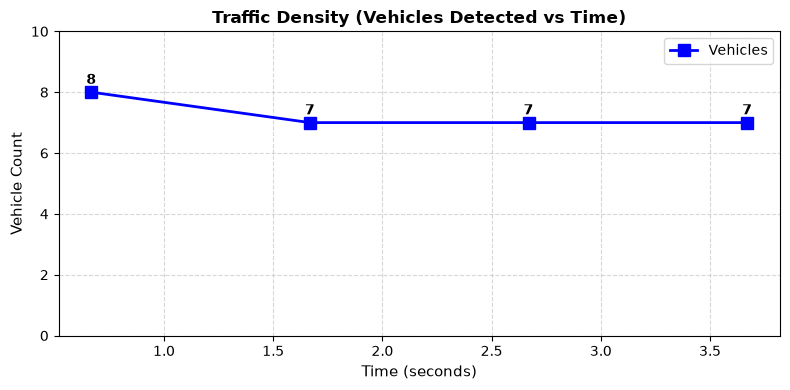

In [6]:
times = [res['timestamp'] for res in sampled_car_results]
counts = [res['count'] for res in sampled_car_results]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(times, counts, marker='s', color='blue', linewidth=2, markersize=8, label='Vehicles')

for t, c in zip(times, counts):
    ax.annotate(f'{c}', xy=(t, c), xytext=(0, 6), textcoords="offset points",
                ha='center', fontweight='bold')

ax.set_title("Traffic Density (Vehicles Detected vs Time)", fontsize=12, fontweight='bold')
ax.set_xlabel("Time (seconds)", fontsize=11)
ax.set_ylabel("Vehicle Count", fontsize=11)
if counts:
    ax.set_ylim(0, max(counts) + 2)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


<a id="6-complete-standalone-video-playback-loop"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">6. Complete Standalone Video Playback Loop</span>

Press **`q`** or **`ESC`** on the preview window to exit cleanly.

In [7]:
def play_car_video(video_path, max_frames=120):
    """Play vehicle detection preview in a desktop OpenCV window."""
    if not os.path.exists(video_path):
        print(f"Error: Video file not found at '{video_path}'.")
        return

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video file at '{video_path}'.")
        return

    classifier = globals().get('car_classifier', None)
    if classifier is None or classifier.empty():
        classifier = cv2.CascadeClassifier('Haarcascades/haarcascade_car.xml')

    frame_counter = 0
    print("Starting vehicle video playback. Press 'q' or 'ESC' on the preview window to stop.")
    
    win_name = 'Vehicle Detection Preview'
    cv2.namedWindow(win_name, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(win_name, 960, 540)
    try:
        cv2.setWindowProperty(win_name, cv2.WND_PROP_TOPMOST, 1)
    except Exception:
        pass

    while cap.isOpened() and (max_frames is None or frame_counter < max_frames):
        ret, frame = cap.read()
        if not ret:
            break
            
        frame_counter += 1
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        cars = classifier.detectMultiScale(gray, scaleFactor=1.15, minNeighbors=3)
        
        for (x, y, w, h) in cars:
            cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 3)
            
        cv2.putText(frame, f"Cars: {len(cars)} | Frame: {frame_counter}",
                    (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 0, 0), 2)
                    
        cv2.imshow(win_name, frame)
        
        key = cv2.waitKey(25) & 0xFF
        if key == 27 or key == ord('q'):
            print(f"Playback stopped at frame {frame_counter}.")
            break
            
    cap.release()
    cv2.destroyAllWindows()
    print("Video capture released cleanly.")


def play_car_video_inline(video_path, max_frames=60, display_width=720):
    """Play vehicle detection directly inside the notebook cell."""
    if not os.path.exists(video_path):
        print(f"Error: Video file not found at '{video_path}'.")
        return

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video file at '{video_path}'.")
        return

    classifier = globals().get('car_classifier', None)
    if classifier is None or classifier.empty():
        classifier = cv2.CascadeClassifier('Haarcascades/haarcascade_car.xml')

    frame_counter = 0
    print(f"Streaming inline preview ({max_frames} frames)...")

    while cap.isOpened() and frame_counter < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        frame_counter += 1

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        cars = classifier.detectMultiScale(gray, scaleFactor=1.15, minNeighbors=3)

        for (x, y, w, h) in cars:
            cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 3)

        cv2.putText(frame, f"Cars: {len(cars)} | Frame: {frame_counter}",
                    (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 0, 0), 2)

        h, w = frame.shape[:2]
        display_height = int(h * (display_width / w))
        rgb = cv2.cvtColor(cv2.resize(frame, (display_width, display_height)), cv2.COLOR_BGR2RGB)
        clear_output(wait=True)
        display(Image.fromarray(rgb))

    cap.release()
    print(f"Finished inline preview of {frame_counter} frames.")

In [8]:
# Option A: Live Desktop Window Preview (set on top of other windows):
play_car_video('assets/video/Vehicles.mp4', max_frames=120)


Starting vehicle video playback. Press 'q' or 'ESC' on the preview window to stop.
Video capture released cleanly.


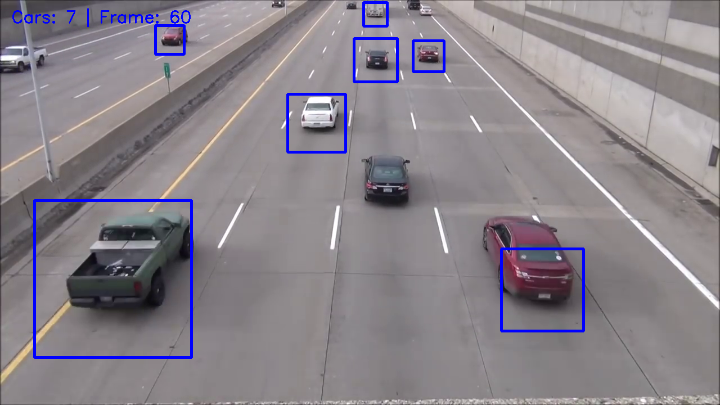

Finished inline preview of 60 frames.


In [9]:
# Option B: Inline Notebook Preview (plays directly inside the cell):
play_car_video_inline('assets/video/Vehicles.mp4', max_frames=60)

<a id="7-key-takeaways"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">7. Key Takeaways</span>

- **Vehicle Cascades**: Capture contrast contours of vehicle rears and windshields.
- **Traffic Analytics**: Tracking detection counts over time serves as the foundation for congestion monitoring and flow analysis.
- **Next Step**: In Notebook 06, we focus on vehicle license plates and apply privacy-preserving image blurring.